In [3]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("cleaned_timeseries.csv")

In [5]:
# Load cleaned data
df = pd.read_csv("cleaned_timeseries.csv")

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Set date as index
df.set_index("date", inplace=True)

# Check
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 454 entries, 2013-01-02 to 2014-03-31
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unit_sales  454 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


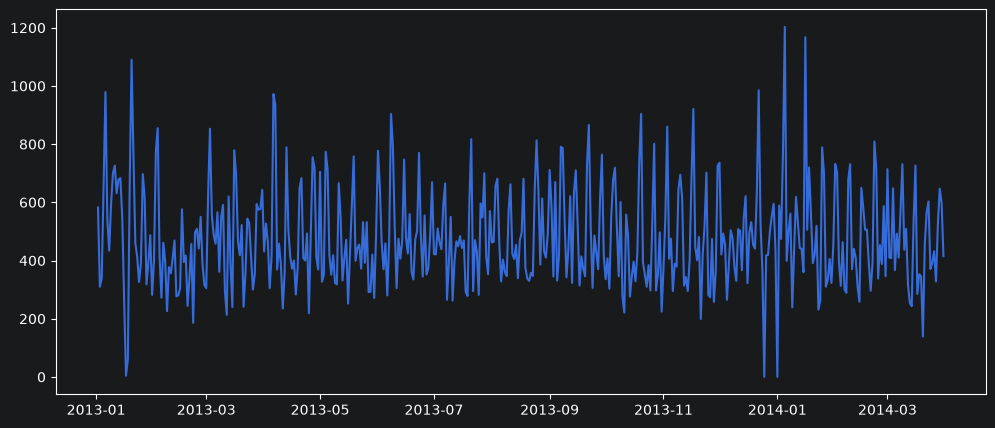

In [6]:
plt.figure(figsize=(12,5))
plt.plot(df["unit_sales"])
plt.show()

In [7]:
# Create a copy of the cleaned dataset
df_features = df.copy()

# Calendar features
df_features['year'] = df_features.index.year
df_features['month'] = df_features.index.month

df_features['day'] = df_features.index.day

df_features['day_of_week'] = df_features.index.dayofweek

df_features['week_of_year'] = df_features.index.isocalendar().week.astype(int)

df_features['quarter'] = df_features.index.quarter

df_features['is_weekend'] = df_features.index.dayofweek >= 5

df_features.head()

,unit_sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend
date,,,,,,,,
2013-01-02,582.0,2013,1,2,2,1,1,False
2013-01-03,310.0,2013,1,3,3,1,1,False
2013-01-04,338.0,2013,1,4,4,1,1,False
2013-01-05,654.0,2013,1,5,5,1,1,True
2013-01-06,979.0,2013,1,6,6,1,1,True


In [8]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 454 entries, 2013-01-02 to 2014-03-31
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unit_sales  454 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


In [9]:
df_features

,unit_sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend
date,,,,,,,,
2013-01-02,582.0,2013,1,2,2,1,1,False
2013-01-03,310.0,2013,1,3,3,1,1,False
2013-01-04,338.0,2013,1,4,4,1,1,False
2013-01-05,654.0,2013,1,5,5,1,1,True
2013-01-06,979.0,2013,1,6,6,1,1,True
...,...,...,...,...,...,...,...,...
2014-03-27,328.0,2014,3,27,3,13,1,False
2014-03-28,523.0,2014,3,28,4,13,1,False
2014-03-29,647.0,2014,3,29,5,13,1,True


In [10]:
# Lag features (per store and item)
# Lag features
df_features["lag_1"] = df_features["unit_sales"].shift(1)
df_features["lag_7"] = df_features["unit_sales"].shift(7)
df_features["lag_14"] = df_features["unit_sales"].shift(14)
df_features["lag_30"] = df_features["unit_sales"].shift(30)

df_features.head(35)

,unit_sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_14,lag_30
date,,,,,,,,,,,,
2013-01-02,582.0,2013,1,2,2,1,1,False,NaN,NaN,NaN,NaN
2013-01-03,310.0,2013,1,3,3,1,1,False,582.0,NaN,NaN,NaN
2013-01-04,338.0,2013,1,4,4,1,1,False,310.0,NaN,NaN,NaN
2013-01-05,654.0,2013,1,5,5,1,1,True,338.0,NaN,NaN,NaN
2013-01-06,979.0,2013,1,6,6,1,1,True,654.0,NaN,NaN,NaN
2013-01-07,541.0,2013,1,7,0,2,1,False,979.0,NaN,NaN,NaN
2013-01-08,434.0,2013,1,8,1,2,1,False,541.0,NaN,NaN,NaN
2013-01-09,593.0,2013,1,9,2,2,1,False,434.0,582.0,NaN,NaN
2013-01-10,700.0,2013,1,10,3,2,1,False,593.0,310.0,NaN,NaN


In [11]:
# Rolling averages
df_features["rolling_mean_7"] = (
    df_features["unit_sales"]
    .rolling(window=7)
    .mean()
)

df_features["rolling_mean_30"] = (
    df_features["unit_sales"]
    .rolling(window=30)
    .mean()
)

In [12]:
# Rolling standard deviation
df_features["rolling_std_7"] = (
    df_features["unit_sales"]
    .rolling(window=7)
    .std()
)

df_features["rolling_std_30"] = (
    df_features["unit_sales"]
    .rolling(window=30)
    .std()
)

In [13]:
df_features[
    [
        "unit_sales",
        "rolling_mean_7",
        "rolling_std_7",
        "rolling_mean_30",
        "rolling_std_30",
    ]
].head(35)

,unit_sales,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30
date,,,,,
2013-01-02,582.0,NaN,NaN,NaN,NaN
2013-01-03,310.0,NaN,NaN,NaN,NaN
2013-01-04,338.0,NaN,NaN,NaN,NaN
2013-01-05,654.0,NaN,NaN,NaN,NaN
2013-01-06,979.0,NaN,NaN,NaN,NaN
2013-01-07,541.0,NaN,NaN,NaN,NaN
2013-01-08,434.0,548.285714,228.013680,NaN,NaN
2013-01-09,593.0,549.857143,228.322454,NaN,NaN
2013-01-10,700.0,605.571429,206.587235,NaN,NaN


In [14]:
df_features.isnull().sum()

unit_sales          0
year                0
month               0
day                 0
day_of_week         0
week_of_year        0
quarter             0
is_weekend          0
lag_1               1
lag_7               7
lag_14             14
lag_30             30
rolling_mean_7      6
rolling_mean_30    29
rolling_std_7       6
rolling_std_30     29
dtype: int64

In [15]:
df_features.columns

Index(['unit_sales', 'year', 'month', 'day', 'day_of_week', 'week_of_year',
       'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30',
       'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30'],
      dtype='str')

In [16]:
print(df_features.isnull().sum())

unit_sales          0
year                0
month               0
day                 0
day_of_week         0
week_of_year        0
quarter             0
is_weekend          0
lag_1               1
lag_7               7
lag_14             14
lag_30             30
rolling_mean_7      6
rolling_mean_30    29
rolling_std_7       6
rolling_std_30     29
dtype: int64


In [17]:
def is_weekend(x):
    if x >= 5:
        return 1
    else:
        return 0

df_features['is_weekend'] = df_features['day_of_week'].apply(is_weekend)

In [18]:
oil = pd.read_csv("oil.csv")

In [19]:
oil["date"] = pd.to_datetime(oil["date"])

In [20]:
oil["dcoilwtico"] = oil["dcoilwtico"].ffill()

In [21]:
# Linking oil prices to sales data
oil.set_index("date", inplace=True)

In [22]:
df_features = df_features.join(
    oil["dcoilwtico"],
    how="left"
)

In [23]:
df_features.head()

,unit_sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,dcoilwtico
date,,,,,,,,,,,,,,,,,
2013-01-02,582.0,2013,1,2,2,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.14
2013-01-03,310.0,2013,1,3,3,1,1,0,582.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.97
2013-01-04,338.0,2013,1,4,4,1,1,0,310.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.12
2013-01-05,654.0,2013,1,5,5,1,1,1,338.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-06,979.0,2013,1,6,6,1,1,1,654.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
holidays = pd.read_csv("holidays.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

In [25]:
holidays["is_holiday"] = True

In [26]:
holidays = holidays[["date", "is_holiday"]]

In [27]:
holidays.set_index("date", inplace=True)

In [28]:
df_features = df_features.join(
    holidays,
    how="left"
)

In [29]:
df_features["is_holiday"] = (
    df_features["is_holiday"]
    .fillna(False)
)

In [30]:
df_features.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 459 entries, 2013-01-02 to 2014-03-31
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   unit_sales       459 non-null    float64
 1   year             459 non-null    int32  
 2   month            459 non-null    int32  
 3   day              459 non-null    int32  
 4   day_of_week      459 non-null    int32  
 5   week_of_year     459 non-null    int64  
 6   quarter          459 non-null    int32  
 7   is_weekend       459 non-null    int64  
 8   lag_1            458 non-null    float64
 9   lag_7            452 non-null    float64
 10  lag_14           445 non-null    float64
 11  lag_30           429 non-null    float64
 12  rolling_mean_7   453 non-null    float64
 13  rolling_mean_30  430 non-null    float64
 14  rolling_std_7    453 non-null    float64
 15  rolling_std_30   430 non-null    float64
 16  dcoilwtico       327 non-null    float64
 17  is_holid

In [34]:
holidays = pd.read_csv("holidays.csv")
# Datum als Datetime
holidays["date"] = pd.to_datetime(holidays["date"])

# Nur eindeutige Datumswerte behalten
holiday_dates = holidays[["date"]].drop_duplicates()

# Feiertags-Flag
holiday_dates["is_holiday"] = 1

# Datum als Index setzen
holiday_dates = holiday_dates.set_index("date")

In [35]:
holidays.head()

,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba


In [41]:
oil = pd.read_csv("oil.csv")

oil["date"] = pd.to_datetime(oil["date"])
oil = oil.set_index("date")

oil["dcoilwtico"] = oil["dcoilwtico"].ffill().bfill()

In [42]:
df_features.columns

Index(['unit_sales', 'year', 'month', 'day', 'day_of_week', 'week_of_year',
       'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30',
       'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30',
       'dcoilwtico', 'is_holiday'],
      dtype='str')

In [43]:
df_features["dcoilwtico"] = df_features["dcoilwtico"].ffill().bfill()

In [44]:
df_features.info()

df_features.isnull().sum()

<class 'pandas.DataFrame'>
DatetimeIndex: 459 entries, 2013-01-02 to 2014-03-31
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   unit_sales       459 non-null    float64
 1   year             459 non-null    int32  
 2   month            459 non-null    int32  
 3   day              459 non-null    int32  
 4   day_of_week      459 non-null    int32  
 5   week_of_year     459 non-null    int64  
 6   quarter          459 non-null    int32  
 7   is_weekend       459 non-null    int64  
 8   lag_1            458 non-null    float64
 9   lag_7            452 non-null    float64
 10  lag_14           445 non-null    float64
 11  lag_30           429 non-null    float64
 12  rolling_mean_7   453 non-null    float64
 13  rolling_mean_30  430 non-null    float64
 14  rolling_std_7    453 non-null    float64
 15  rolling_std_30   430 non-null    float64
 16  dcoilwtico       459 non-null    float64
 17  is_holid

unit_sales          0
year                0
month               0
day                 0
day_of_week         0
week_of_year        0
quarter             0
is_weekend          0
lag_1               1
lag_7               7
lag_14             14
lag_30             30
rolling_mean_7      6
rolling_mean_30    29
rolling_std_7       6
rolling_std_30     29
dcoilwtico          0
is_holiday          0
dtype: int64

In [45]:
df_features.shape

(459, 18)

In [46]:
df_features.columns

Index(['unit_sales', 'year', 'month', 'day', 'day_of_week', 'week_of_year',
       'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30',
       'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30',
       'dcoilwtico', 'is_holiday'],
      dtype='str')

In [47]:
df_features.index.duplicated().sum()

np.int64(5)

In [48]:
# double date remove
df_features = df_features[~df_features.index.duplicated(keep="first")]

In [49]:
df_features.shape

(454, 18)

In [50]:
df_features = df_features.dropna()
df_features.to_csv("feature_engineered.csv")

## Machine Learning Part

In [62]:
df_features["is_holiday"] = df_features["is_holiday"].astype(int)

In [63]:
# Train/Test Split
train = df_features.loc["2013-01-01":"2013-12-31"]
test = df_features.loc["2014-01-01":"2014-03-31"]

In [64]:
test

,unit_sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,dcoilwtico,is_holiday
date,,,,,,,,,,,,,,,,,,
2014-01-01,0.0,2014,1,1,2,1,1,0,436.0,0.0,532.0,421.0,417.000000,450.066667,196.166596,177.364797,98.17,1
2014-01-02,589.0,2014,1,2,3,1,1,0,0.0,418.0,455.0,493.0,441.428571,453.266667,206.677573,179.024355,95.14,0
2014-01-03,474.0,2014,1,3,4,1,1,0,589.0,419.0,441.0,454.0,449.285714,453.933333,206.728255,179.064414,93.66,0
2014-01-04,767.0,2014,1,4,5,1,1,1,474.0,499.0,630.0,265.0,487.571429,470.666667,239.662858,184.182506,93.66,0
2014-01-05,1203.0,2014,1,5,6,1,1,1,767.0,552.0,985.0,388.0,580.571429,497.833333,363.266136,226.754475,93.66,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-03-27,328.0,2014,3,27,3,13,1,0,432.0,139.0,254.0,453.0,449.857143,445.533333,101.609430,148.708865,101.25,0
2014-03-28,523.0,2014,3,28,4,13,1,0,328.0,456.0,243.0,388.0,459.428571,450.033333,105.370548,148.950231,101.73,0
2014-03-29,647.0,2014,3,29,5,13,1,1,523.0,567.0,535.0,587.0,470.857143,452.033333,122.007416,151.237991,101.73,0


In [65]:
X_train = train.drop(columns=["unit_sales"])
y_train = train["unit_sales"]

X_test = test.drop(columns=["unit_sales"])
y_test = test["unit_sales"]

In [66]:
train.columns

Index(['unit_sales', 'year', 'month', 'day', 'day_of_week', 'week_of_year',
       'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30',
       'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30',
       'dcoilwtico', 'is_holiday'],
      dtype='str')

In [67]:
X_train

,year,month,day,day_of_week,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,dcoilwtico,is_holiday
date,,,,,,,,,,,,,,,,,
2013-02-01,2013,2,1,4,5,1,0,282.0,389.0,60.0,582.0,456.285714,514.800000,153.272866,238.098849,97.46,0
2013-02-02,2013,2,2,5,5,1,1,401.0,697.0,667.0,310.0,467.428571,530.300000,174.986530,239.438589,97.46,0
2013-02-03,2013,2,3,6,5,1,1,775.0,616.0,1090.0,338.0,501.571429,547.533333,224.981375,243.688288,97.46,0
2013-02-04,2013,2,4,0,6,1,0,855.0,318.0,760.0,654.0,514.857143,539.433333,214.852219,244.065662,96.21,0
2013-02-05,2013,2,5,1,6,1,0,411.0,393.0,461.0,979.0,497.571429,515.866667,230.581769,234.087625,96.68,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-27,2013,12,27,4,52,4,0,418.0,441.0,367.0,474.0,477.142857,464.133333,297.351323,173.505189,99.94,0
2013-12-28,2013,12,28,5,52,4,1,419.0,630.0,547.0,258.0,458.428571,472.166667,290.163090,169.156749,99.94,0
2013-12-29,2013,12,29,6,52,4,1,499.0,985.0,621.0,363.0,396.571429,478.466667,187.021262,168.468913,99.94,0


In [68]:
y_train

date
2013-02-01    401.0
2013-02-02    775.0
2013-02-03    855.0
2013-02-04    411.0
2013-02-05    272.0
              ...  
2013-12-27    419.0
2013-12-28    499.0
2013-12-29    552.0
2013-12-30    595.0
2013-12-31    436.0
Name: unit_sales, Length: 334, dtype: float64

## XGBoost Model

In [69]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [70]:
import sklearn
import xgboost as xgb

print(sklearn.__version__)
print(xgb.__version__)

1.9.0
3.3.0


In [72]:
# Initialize the XGBoost regressor
xgboost_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    )

# Train the XGBoost model
xgboost_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [73]:
X_train.dtypes

year                 int32
month                int32
day                  int32
day_of_week          int32
week_of_year         int64
quarter              int32
is_weekend           int64
lag_1              float64
lag_7              float64
lag_14             float64
lag_30             float64
rolling_mean_7     float64
rolling_mean_30    float64
rolling_std_7      float64
rolling_std_30     float64
dcoilwtico         float64
is_holiday           int64
dtype: object

In [74]:
# make predictions
y_pred = xgboost_model.predict(X_test)

In [75]:
# Evaluate model
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 91.40
RMSE: 143.47
R²: 0.4319


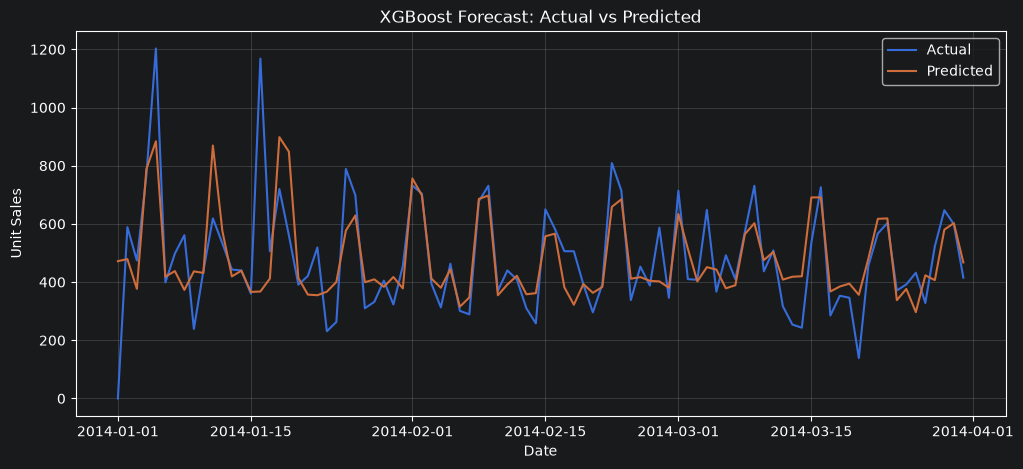

In [76]:
# Actual vs. predicted action
plt.figure(figsize=(12, 5))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")

plt.title("XGBoost Forecast: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The XGBoost model successfully captured the overall sales trend and seasonal fluctuations. Predicted values followed the actual sales reasonably well, although the model tended to smooth sharp peaks and underestimate extreme sales values. This behavior is reflected in the evaluation metrics (MAE = 91.40, RMSE = 143.47, R² = 0.4319), indicating moderate predictive performance with potential for improvement through additional feature engineering and hyperparameter tuning.

## Random Forest Regressor

In [77]:
from sklearn.ensemble import RandomForestRegressor

In [78]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [79]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [80]:
rf_pred = rf_model.predict(X_test)

In [81]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 88.88
RMSE: 141.29
R²: 0.4490


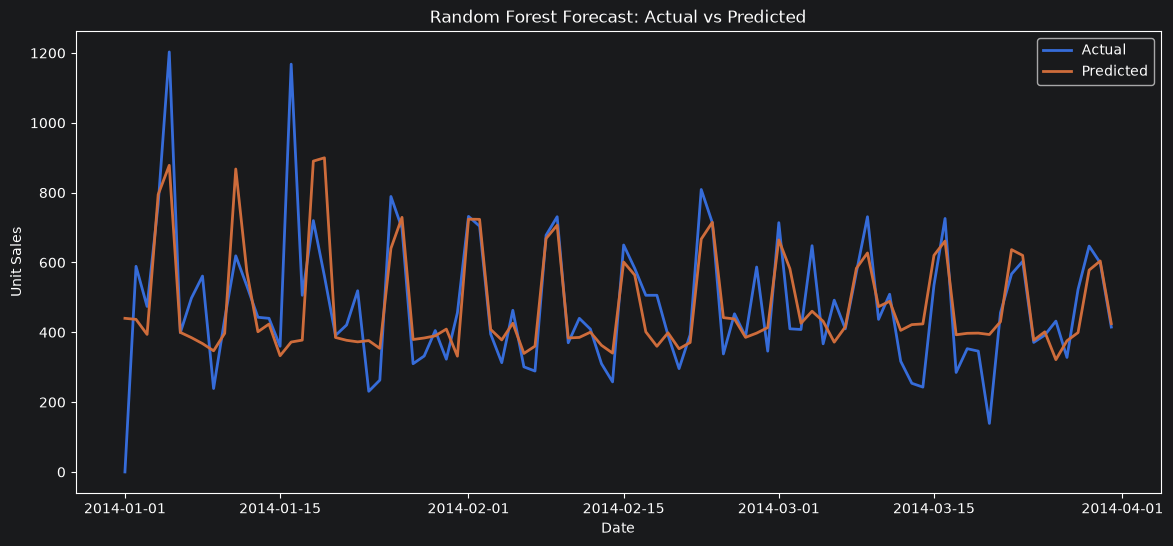

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    test.index,
    y_test,
    label="Actual",
    linewidth=2
)

plt.plot(
    test.index,
    rf_pred,
    label="Predicted",
    linewidth=2
)

plt.title("Random Forest Forecast: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()

plt.show()

The Random Forest model slightly outperformed XGBoost, achieving a lower MAE and RMSE and a higher R² score. The model captures the overall sales pattern reasonably well, but still tends to smooth extreme peaks and low values.

## Linear Regression

In [83]:
from sklearn.linear_model import LinearRegression

In [84]:
lr_model = LinearRegression()

In [85]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](17,)","[ 0. ,13.92, 0.25,...,-0.18,-0.97, 0.96]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](17,)","['year','month','day',...,'rolling_std_30','dcoilwtico','is_holiday']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.249
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,17
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(16)


In [86]:
lr_pred = lr_model.predict(X_test)

In [87]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, lr_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
r2 = r2_score(y_test, lr_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 90.85
RMSE: 134.22
R²: 0.5028


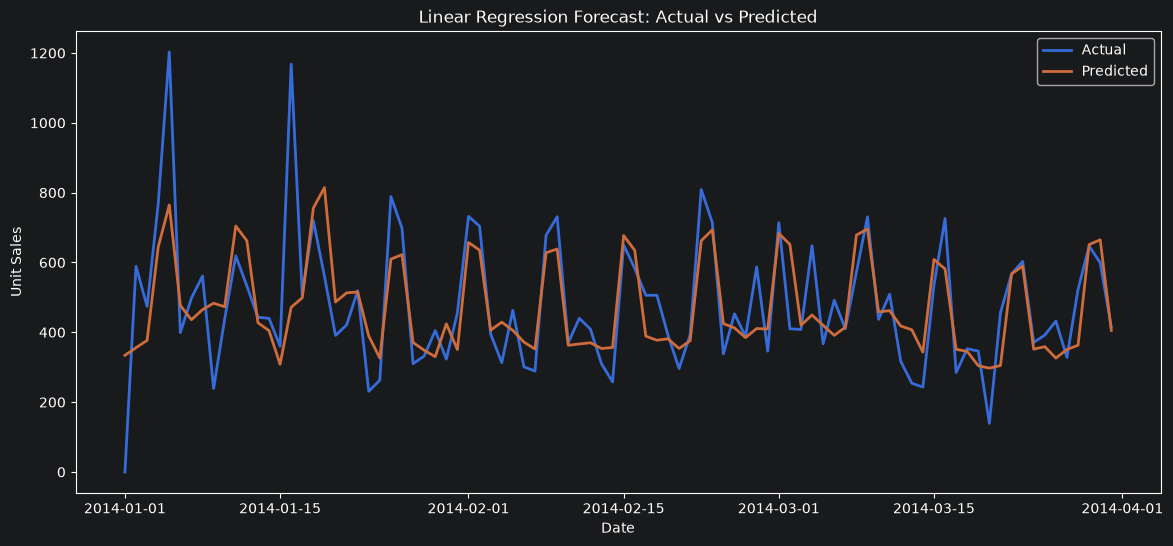

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(test.index, y_test, label="Actual", linewidth=2)
plt.plot(test.index, lr_pred, label="Predicted", linewidth=2)

plt.title("Linear Regression Forecast: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()

plt.show()

Three regression models were trained and evaluated: Linear Regression, Random Forest, and XGBoost. Although Random Forest achieved the lowest MAE, Linear Regression obtained the lowest RMSE (134.22) and the highest coefficient of determination (R² = 0.5028). Therefore, Linear Regression provided the best overall predictive performance on the test set and was selected as the final model.

| Modell            |     MAE ↓ |     RMSE ↓ |       R² ↑ | Bewertung        |
| ----------------- | --------: | ---------: | ---------: | ---------------- |
| Linear Regression | **90.85** | **134.22** | **0.5028** | ⭐ Bestes Modell  |
| Random Forest     | **88.88** |     141.29 |     0.4490 | Gute Performance |
| XGBoost           |     91.40 |     143.47 |     0.4319 | Gute Performance |


## Forecasting

In [89]:
def iterative_forecast(model, train_df, n_future_days, oil_data=None, holiday_dates=None):
    history = train_df["unit_sales"].copy()
    forecasts = []

    last_date = history.index[-1]

    for i in range(1, n_future_days + 1):
        next_date = last_date + pd.Timedelta(days=i)

        # Lag features
        lag_1 = history.iloc[-1]
        lag_7 = history.iloc[-7]
        lag_14 = history.iloc[-14]
        lag_30 = history.iloc[-30]

        # Rolling features
        rolling_mean_7 = history.iloc[-7:].mean()
        rolling_mean_30 = history.iloc[-30:].mean()
        rolling_std_7 = history.iloc[-7:].std()
        rolling_std_30 = history.iloc[-30:].std()

        # Calendar features
        year = next_date.year
        month = next_date.month
        day = next_date.day
        day_of_week = next_date.dayofweek
        week_of_year = next_date.isocalendar().week
        quarter = next_date.quarter
        is_weekend = int(day_of_week >= 5)

        # Oil price
        if oil_data is not None and next_date in oil_data.index:
            dcoilwtico = oil_data.loc[next_date, "dcoilwtico"]
        else:
            dcoilwtico = train_df["dcoilwtico"].iloc[-1]

        # Holiday
        if holiday_dates is not None:
            is_holiday = int(next_date in holiday_dates.index)
        else:
            is_holiday = 0

        row = pd.DataFrame({
            "year": [year],
            "month": [month],
            "day": [day],
            "day_of_week": [day_of_week],
            "week_of_year": [week_of_year],
            "quarter": [quarter],
            "is_weekend": [is_weekend],
            "lag_1": [lag_1],
            "lag_7": [lag_7],
            "lag_14": [lag_14],
            "lag_30": [lag_30],
            "rolling_mean_7": [rolling_mean_7],
            "rolling_mean_30": [rolling_mean_30],
            "rolling_std_7": [rolling_std_7],
            "rolling_std_30": [rolling_std_30],
            "dcoilwtico": [dcoilwtico],
            "is_holiday": [is_holiday]
        })

        # gleiche Spalten-Reihenfolge wie beim Training
        row = row[X_train.columns]

        yhat = model.predict(row)[0]

        forecasts.append({
            "date": next_date,
            "predicted_unit_sales": yhat
        })

        history.loc[next_date] = yhat

    return pd.DataFrame(forecasts)

# Forecasting für Linear Regression

In [90]:
future_forecast = iterative_forecast(
    model=lr_model,
    train_df=train,
    n_future_days=90,
    oil_data=oil,
    holiday_dates=holiday_dates
)

future_forecast.head()

,date,predicted_unit_sales
0,2014-01-01,337.307070
1,2014-01-02,410.410239
2,2014-01-03,408.647967
3,2014-01-04,642.660166
4,2014-01-05,716.788792


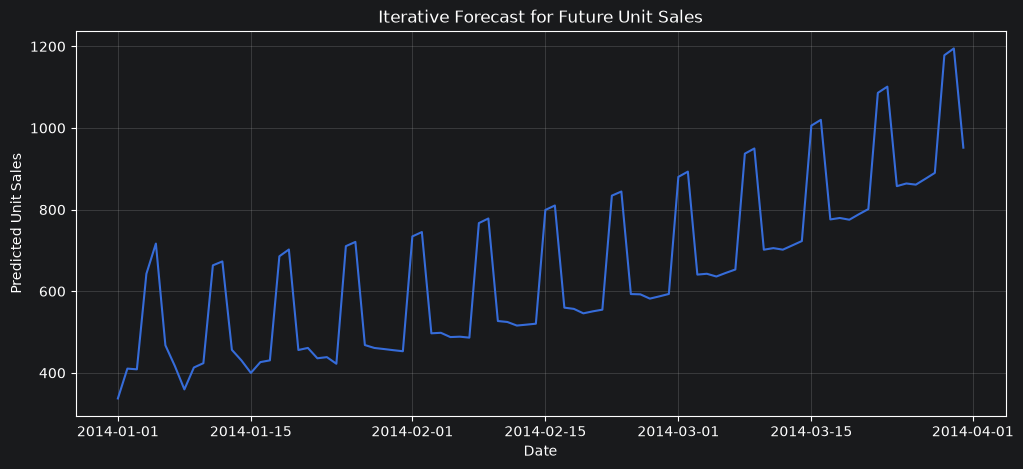

In [91]:
plt.figure(figsize=(12, 5))

plt.plot(future_forecast["date"], future_forecast["predicted_unit_sales"])

plt.title("Iterative Forecast for Future Unit Sales")
plt.xlabel("Date")
plt.ylabel("Predicted Unit Sales")
plt.grid(alpha=0.3)

plt.show()

# Forecasting for Random Forest

In [92]:
rf_forecast = iterative_forecast(
    model=rf_model,
    train_df=train,
    n_future_days=90,
    oil_data=oil,
    holiday_dates=holiday_dates
)

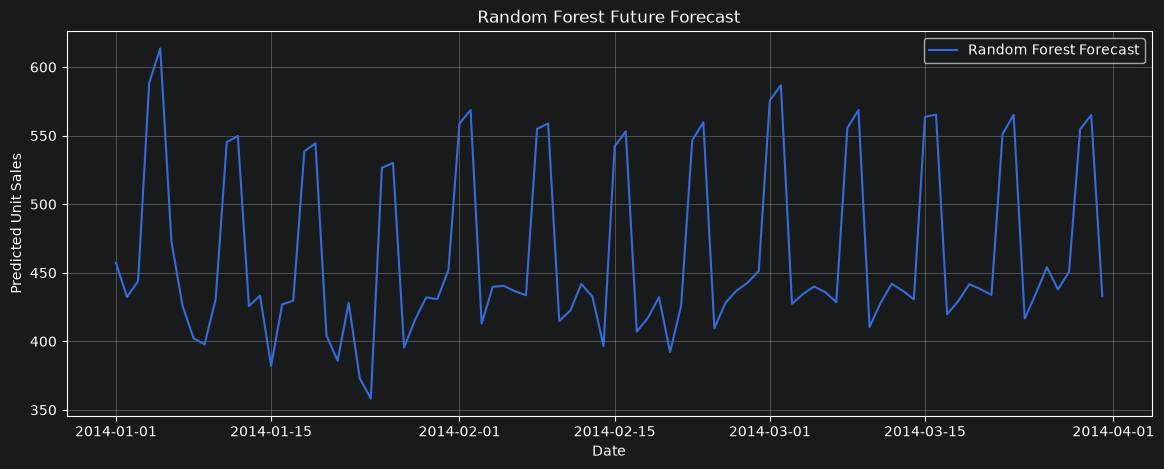

In [93]:
plt.figure(figsize=(14,5))

plt.plot(
    rf_forecast["date"],
    rf_forecast["predicted_unit_sales"],
    label="Random Forest Forecast"
)

plt.title("Random Forest Future Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Unit Sales")
plt.grid(True)
plt.legend()

plt.show()

# Forecasting for XGBoost

In [94]:
xgb_forecast = iterative_forecast(
    model=xgboost_model,
    train_df=train,
    n_future_days=90,
    oil_data=oil,
    holiday_dates=holiday_dates
)

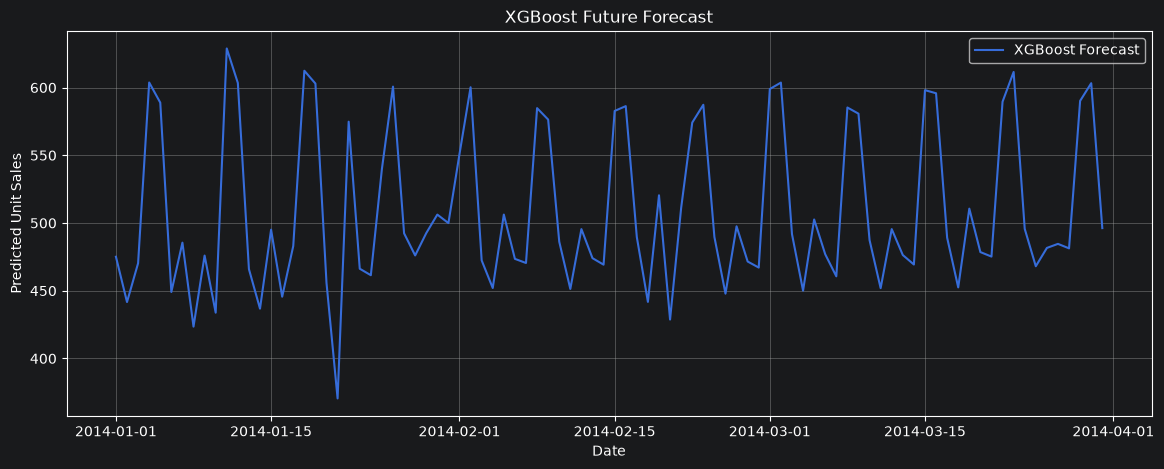

In [95]:
plt.figure(figsize=(14,5))

plt.plot(
    xgb_forecast["date"],
    xgb_forecast["predicted_unit_sales"],
    label="XGBoost Forecast"
)

plt.title("XGBoost Future Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Unit Sales")
plt.grid(True)
plt.legend()

plt.show()

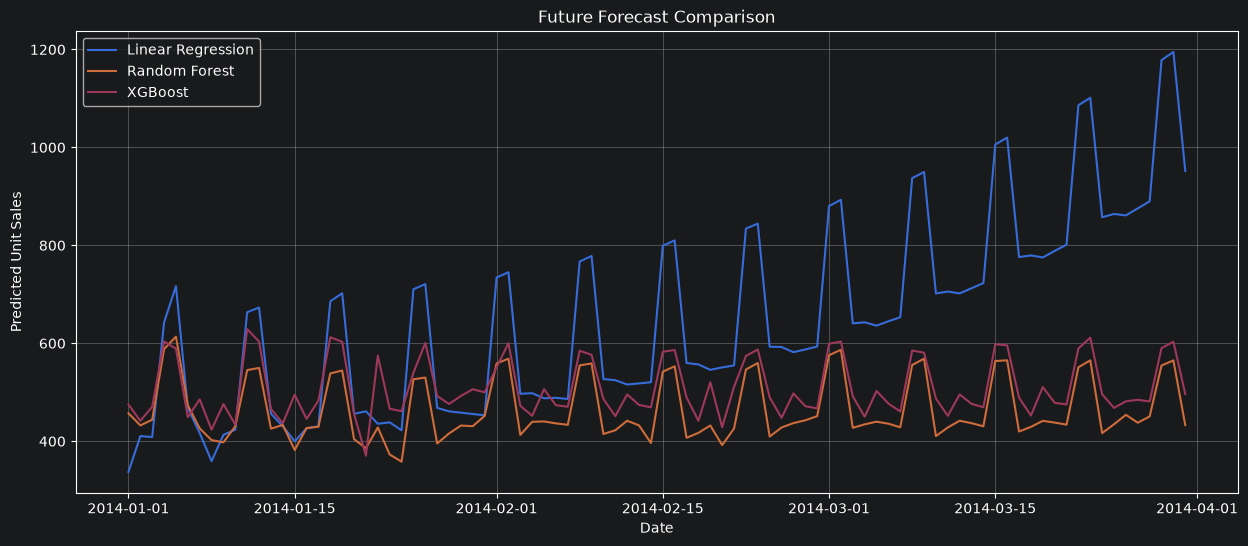

In [96]:
plt.figure(figsize=(15,6))

plt.plot(
    future_forecast["date"],
    future_forecast["predicted_unit_sales"],
    label="Linear Regression"
)

plt.plot(
    rf_forecast["date"],
    rf_forecast["predicted_unit_sales"],
    label="Random Forest"
)

plt.plot(
    xgb_forecast["date"],
    xgb_forecast["predicted_unit_sales"],
    label="XGBoost"
)

plt.title("Future Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Predicted Unit Sales")

plt.legend()
plt.grid(True)

plt.show()

| Model             |     MAE ↓ |     RMSE ↓ |      R² ↑ | Future Forecast          |
| ----------------- | --------: | ---------: | --------: | ------------------------ |
| Linear Regression |     90.85 | **134.22** | **0.503** | Unrealistic upward trend |
| Random Forest     | **88.88** |     141.29 |     0.449 | Stable and realistic     |
| XGBoost           |     91.40 |     143.47 |     0.432 | Stable and realistic     |


# Conclusion

Among the three evaluated models, Linear Regression achieved the best performance on the test dataset according to R² and RMSE. However, its iterative future forecasts exhibited an unrealistic upward trend, limiting its usefulness for long-term forecasting.

Random Forest generated the most stable and realistic future forecasts while maintaining competitive evaluation metrics. XGBoost produced similar results but was slightly less accurate than Random Forest.

Considering both predictive accuracy and forecast stability, Random Forest was selected as the final forecasting model, as it provides the best balance between model performance and realistic long-term predictions.

In [99]:
train.columns

Index(['unit_sales', 'year', 'month', 'day', 'day_of_week', 'week_of_year',
       'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30',
       'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30',
       'dcoilwtico', 'is_holiday'],
      dtype='str')

In [100]:
test.columns

Index(['unit_sales', 'year', 'month', 'day', 'day_of_week', 'week_of_year',
       'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30',
       'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30',
       'dcoilwtico', 'is_holiday'],
      dtype='str')

In [101]:
train.index

DatetimeIndex(['2013-02-01', '2013-02-02', '2013-02-03', '2013-02-04',
               '2013-02-05', '2013-02-06', '2013-02-07', '2013-02-08',
               '2013-02-09', '2013-02-10',
               ...
               '2013-12-22', '2013-12-23', '2013-12-24', '2013-12-25',
               '2013-12-26', '2013-12-27', '2013-12-28', '2013-12-29',
               '2013-12-30', '2013-12-31'],
              dtype='datetime64[us]', name='date', length=334, freq=None)

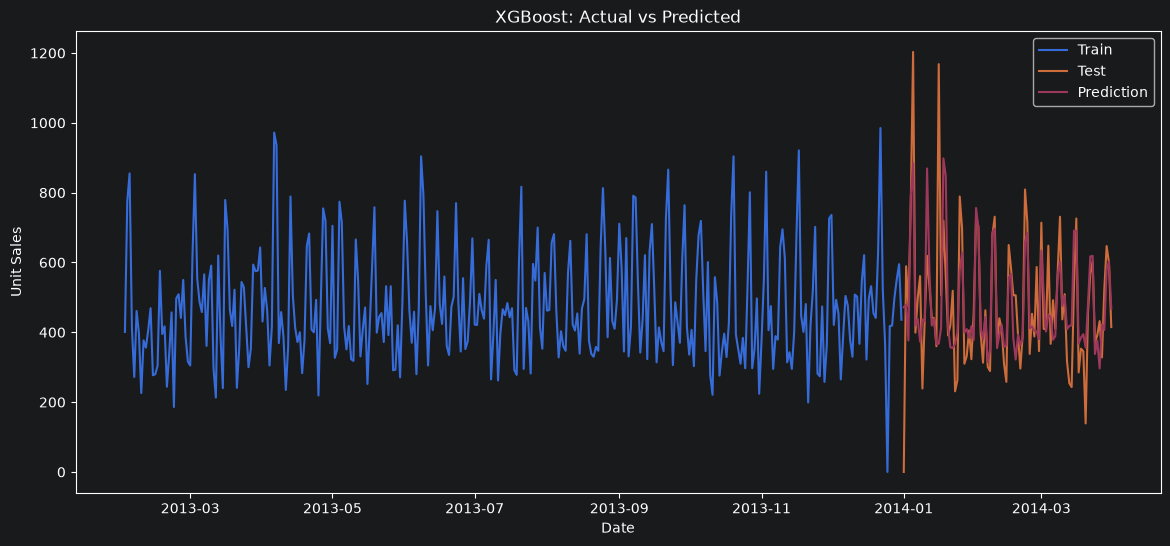

In [118]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train["unit_sales"], label="Train")
plt.plot(test.index, test["unit_sales"], label="Test")
plt.plot(test.index, y_pred, label="Prediction")

plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Unit Sales")

plt.legend()
plt.show()

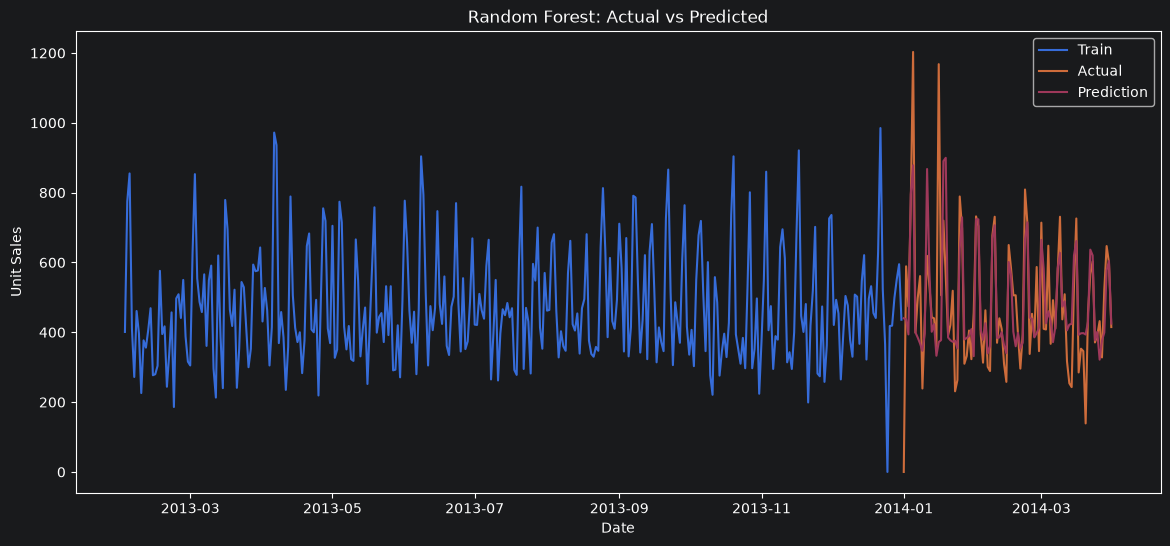

In [114]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train["unit_sales"], label="Train")
plt.plot(test.index, test["unit_sales"], label="Actual")
plt.plot(test.index, rf_pred, label="Prediction")

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()

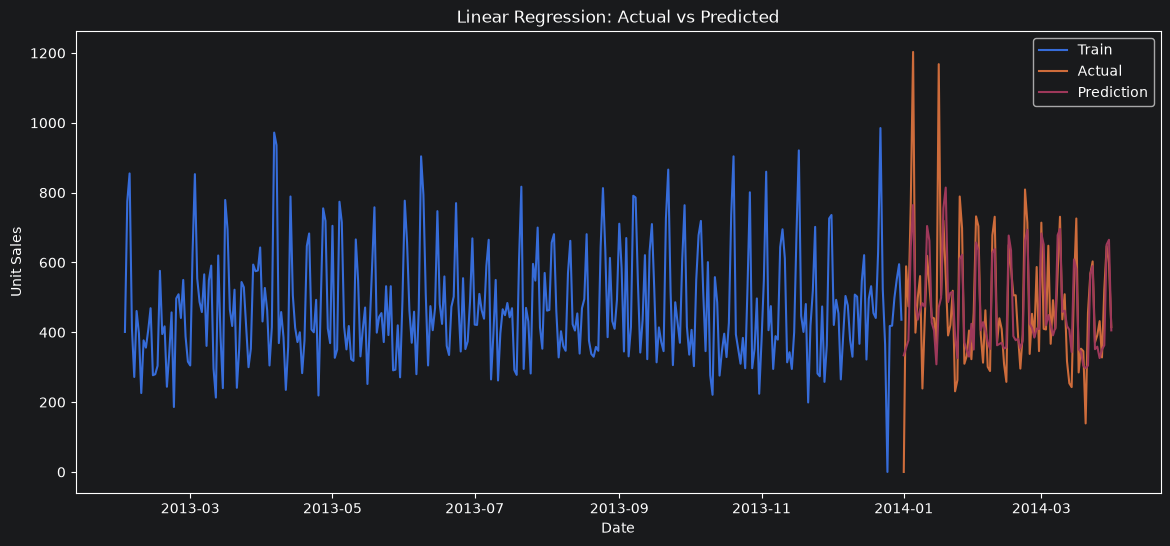

In [119]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train["unit_sales"], label="Train")
plt.plot(test.index, test["unit_sales"], label="Actual")
plt.plot(test.index, lr_pred, label="Prediction")

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()

## Actual vs Predicted Sales

The figure compares the actual sales values in the test period with the model predictions.

The model successfully captures the overall sales pattern and follows the recurring weekly fluctuations. Most peaks and drops are predicted at approximately the correct time, indicating that the engineered lag and calendar features provide useful information for forecasting.

However, the model tends to smooth the predictions and underestimates several extreme sales peaks. While the overall trend is well represented, the predicted values show lower variability than the actual observations.

Overall, the model demonstrates a good ability to capture the general behavior of the time series, although forecasting very high demand remains challenging.

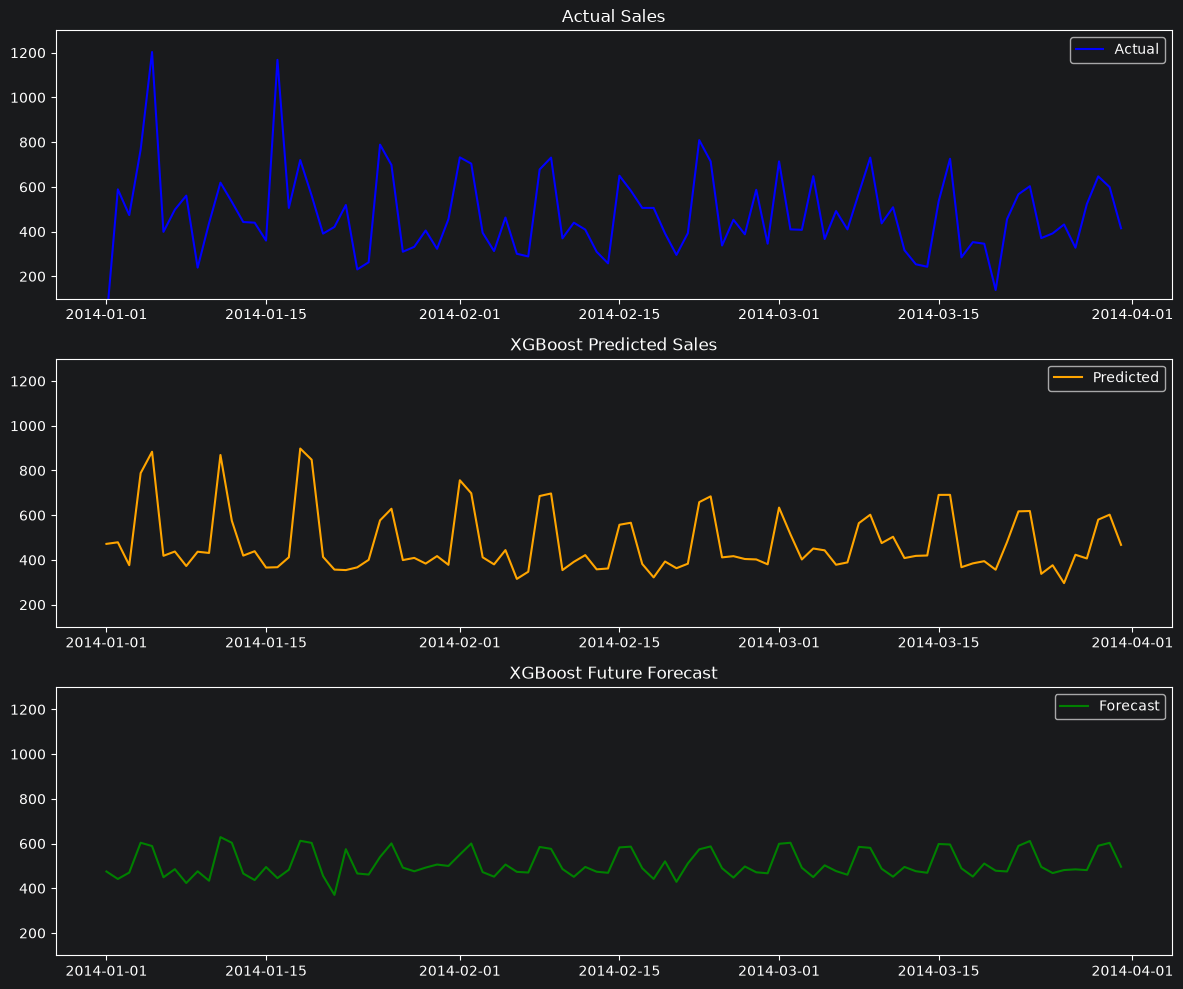

In [135]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Actual values
axes[0].plot(test.index, test["unit_sales"], label="Actual", color="blue")
axes[0].set_title("Actual Sales")
axes[0].set_ylim(100, 1300)
axes[0].legend()

# Predicted values XGBoost
axes[1].plot(test.index, y_pred, label="Predicted", color="orange")
axes[1].set_title("XGBoost Predicted Sales")
axes[1].set_ylim(100, 1300)
axes[1].legend()

axes[2].plot(xgb_forecast["date"],xgb_forecast["predicted_unit_sales"], label="Forecast", color="green")
axes[2].set_title("XGBoost Future Forecast")
axes[2].set_ylim(100, 1300)
axes[2].legend()

plt.tight_layout()
plt.show()

**Prediction on the test set:** The model captures the overall sales dynamics and recurring seasonal fluctuations. While extreme peaks are slightly underestimated, the predictions closely follow the observed pattern, which is consistent with the evaluation metrics obtained on the test data.

**Future forecasting:** The iterative forecast produces stable and realistic future sales estimates. Weekly seasonal patterns are preserved, and no unrealistic trends are observed. Compared to the test predictions, the future forecast is smoother because each predicted value is recursively used as input for subsequent predictions. This behaviour is expected in iterative multi-step forecasting and indicates that the model generates plausible long-term forecasts.